In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

In [ ]:
df = pd.read_csv("samplesuperstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [ ]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [ ]:
# Missing values
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [ ]:
# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

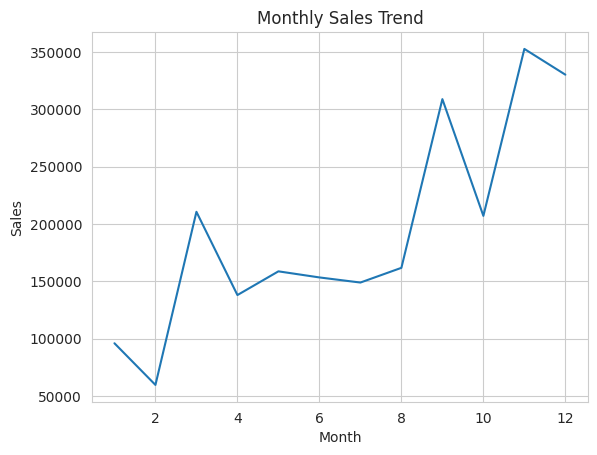

In [ ]:
#Sales Trend Over Time
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure()
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

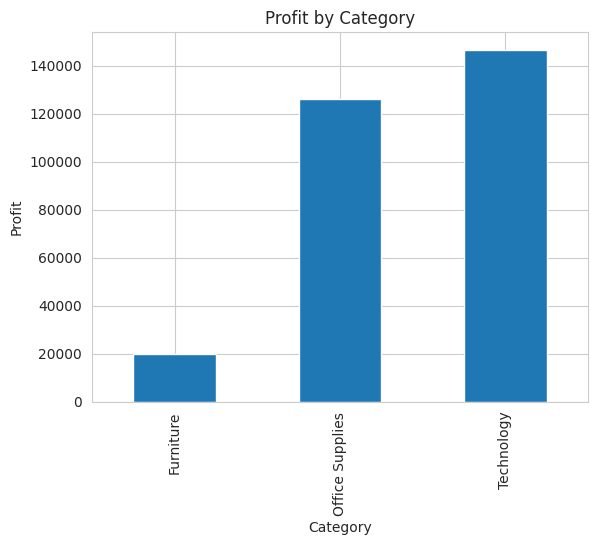

In [ ]:
# Profit by Category
category_profit = df.groupby('Category')['Profit'].sum()

plt.figure()
category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

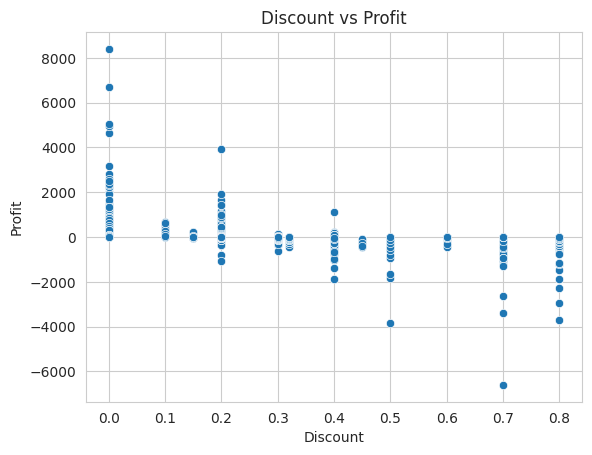

In [ ]:
# Discount vs Profit
plt.figure()
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

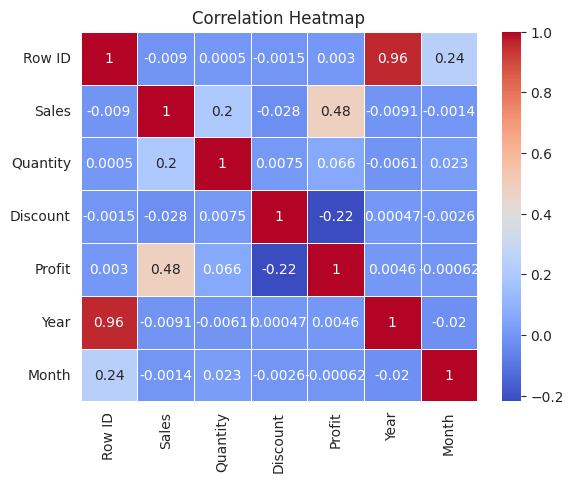

In [ ]:
import pandas as pd

# Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

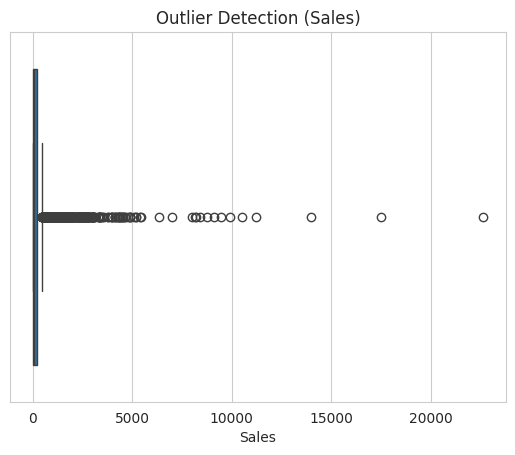

In [ ]:
# Outlier Detection (Sales)
plt.figure()
sns.boxplot(x=df['Sales'])
plt.title("Outlier Detection (Sales)")
plt.show()

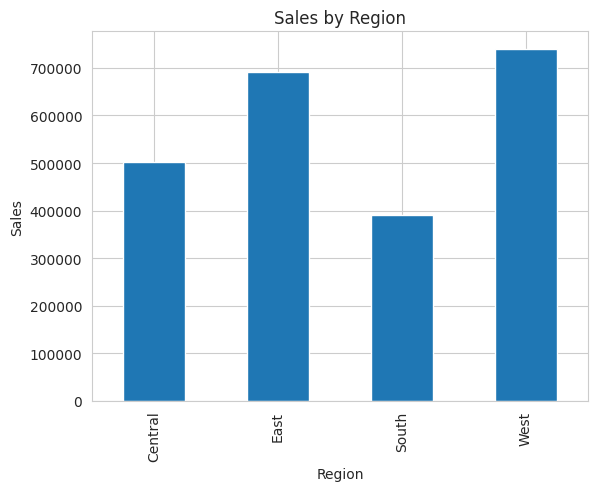

In [ ]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure()
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

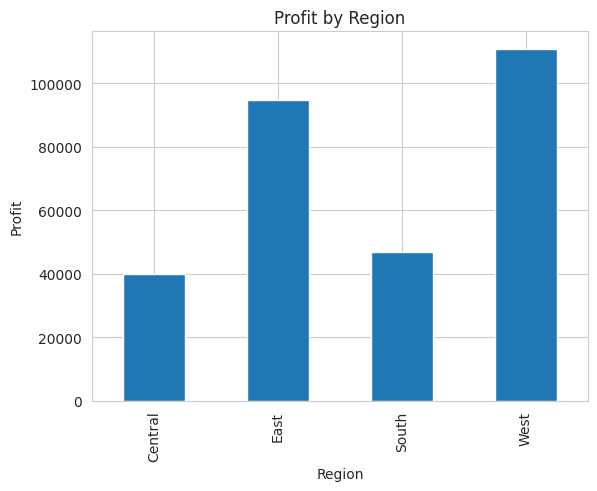

In [ ]:
# Profit by Region
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure()
region_profit.plot(kind='bar')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

Certain regions generate high sales but comparatively lower profit, indicating inefficiencies in pricing or logistics.

Text(0.5, 1.0, 'Top 10 Products by Sales')

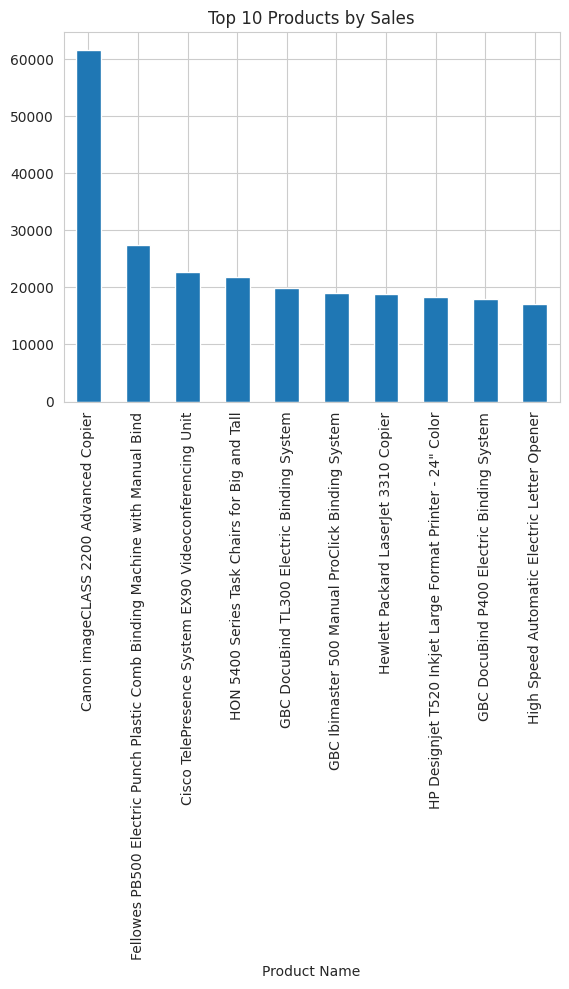

In [ ]:
# Top 10 Products
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")

A limited number of products drive most of the sales,
indicating the importance of inventory focus and promotion strategies.

# **Summary**

**Dataset Overview**

This analysis uses the Superstore retail dataset (~10,000+ transactions) containing sales, profit, discount, product category, customer, and regional data. The objective is to identify key drivers of revenue and profitability through exploratory data analysis and visualizations.

**Key Insights**

1. Discounts are reducing profitability
Higher discount levels consistently correlate with lower or negative profit. Several transactions with deep discounts result in losses.
Implication: Sales growth driven by discounts is not sustainable without margin control.

2. Category performance is inconsistent
Technology and Office Supplies contribute positively to profit, while Furniture frequently underperforms despite reasonable sales volume.
Implication: High sales do not guarantee profitability; pricing or cost inefficiencies exist in certain categories.

3. Regional imbalance in profit vs sales
Some regions generate strong sales but comparatively weaker profit, indicating operational inefficiencies such as higher logistics costs or excessive discounting.
Implication: Regional strategies need to focus on profit optimization, not just revenue growth.

4. Clear seasonality in sales trends
Monthly sales patterns show recurring peaks and dips, suggesting predictable seasonal demand.
Implication: Inventory and marketing efforts can be aligned with peak demand periods to maximize revenue.

5. Revenue concentration among few customers and products
A small subset of customers and products accounts for a large share of total sales.
Implication: Business is dependent on key contributors, creating both an opportunity for targeted engagement and a risk if these customers are lost.

**Conclusion**

The analysis highlights a critical gap between sales and profitability. Sustainable growth requires better control over discounting, improved category-level strategy, and a stronger focus on high-value segments and regions.